# Tutorial 2: Higher-order interactions and FIxLIP paper reproduction

**A case study with shapiq, ViT-B/16 (intra-image), and CLIP (cross-modal).**

First-order Shapley values distribute the model prediction across image regions but cannot, by construction, express **how regions interact**. Sections 1–8 show how to compute exact higher-order interactions (k-SII, STII) on a ViT-B/16 classification game.

Section 10 reproduces the key methodology of **FIxLIP** (Baniecki et al., NeurIPS 2025): explaining CLIP image–text similarity with weighted Banzhaf interactions. We define the cross-modal game, approximate FIxLIP-$p$ with a small `RegressionFixLIP` helper (kernel weights tied to $p$), and decompose the result into intra-image, intra-text, and cross-modal interaction blocks.

**References:**
- FIxLIP: Baniecki et al., *Explaining Similarity in Vision–Language Encoders with Weighted Banzhaf Interactions*, arXiv:2508.05430, 2025.
- shapiq: Muschalik et al., *shapiq: Shapley Interactions for Machine Learning*, NeurIPS 2024.


## 1. Setup

We use ViT-B/16 (`google/vit-base-patch16-224`) on a single image with a 3×3 patch grid as players.
Each player owns a 75×75-pixel block (the patch grid is 14×14 = 196 native ViT tokens, and we group them into 9 macro-regions).

The photo is a golden retriever on Unsplash. We reuse it in Section 10 so ViT’s top class and the CLIP caption refer to the same thing. Tutorial 01 uses a cat-and-dog crop when you want two objects pulling the score in opposite directions.

All seeds are fixed. Since `ExactComputer` evaluates all coalitions exhaustively, results are bit-deterministic given the model and the image.


In [1]:
from __future__ import annotations

from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from torchvision import transforms

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

URL = (
    "https://images.unsplash.com/photo-1591160690555-5debfba289f0?"
    "q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0"
)
raw = Image.open(BytesIO(requests.get(URL, timeout=30).content)).convert("RGB")
pil_image = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])(raw)
image = np.array(pil_image)
print("image:", image.shape)

image: (224, 224, 3)


In [2]:
from transformers import ViTForImageClassification, ViTImageProcessor

VIT_ID = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(VIT_ID)
model = ViTForImageClassification.from_pretrained(VIT_ID).eval().to(device)

with torch.no_grad():
    pred = model(
        pixel_values=processor(images=image, return_tensors="pt")["pixel_values"].to(device)
    ).logits
    target_class = int(pred.argmax(-1).item())
print(f"ViT predicts class {target_class}: {model.config.id2label[target_class]}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT predicts class 207: golden retriever


## 2. Compute exact game values

With 9 players we evaluate the imputer on all $2^9=512$ coalitions using `BoolMaskedPosStrategy` (HuggingFace's `bool_masked_pos` path).

> **Masking note.** `ViTForImageClassification` has no pretrained mask-token embedding (`mask_token = None`). `BoolMaskedPosStrategy` and `MaskTokenStrategy` both initialise a **zero** mask token, so they yield the same coalition scores on this checkpoint. Tutorial 01 compares them side by side; here we use a single masker to avoid duplicate plots. On a MAE-style ViT with a learned mask token the two strategies can diverge—swap in `MaskTokenStrategy` and re-run if you need that comparison.


In [3]:
from shapiq.game_theory.exact import ExactComputer
from shapiq.vision import PatchStrategy, ViTArchitecture
from shapiq.vision.imputer import ImageImputer
from shapiq.vision.masking import BoolMaskedPosStrategy

GRID = model.config.image_size // model.config.patch_size  # 14
patch_strategy = PatchStrategy(grid_size=GRID, n_players=9)  # 3×3 macro-grid

architecture = ViTArchitecture(
    model=model,
    processor=processor,
    masking_strategy=BoolMaskedPosStrategy(),
)
imputer = ImageImputer(
    architecture=architecture,
    image=image,
    player_strategy=patch_strategy,
    batch_size=32,
    normalize=False,
)
computer = ExactComputer(n_players=9, game=imputer)
print("computed game values (512 forward passes)")

computed game values (512 forward passes)


## 3. First-order Shapley values

We start with the standard first-order picture for orientation. Each patch gets one number summarising its average marginal contribution.


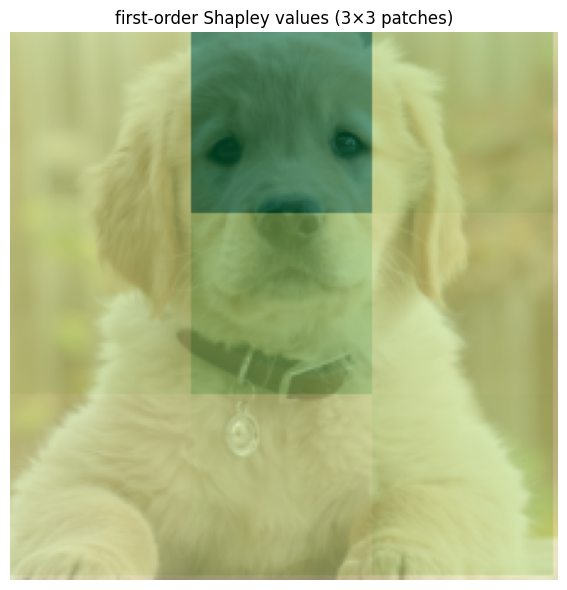

In [4]:
import matplotlib.colors as mcolors
from matplotlib import cm


def patch_heatmap(values, side=3, image_shape=image.shape):
    H, W = image_shape[:2]
    bh, bw = H // side, W // side
    heat = np.zeros((H, W))
    for i, v in enumerate(values):
        y, x = (i // side) * bh, (i % side) * bw
        heat[y : y + bh, x : x + bw] = v
    return heat


def overlay(ax, heat, title):
    ax.imshow(image)
    v = max(abs(heat.min()), abs(heat.max())) + 1e-9
    ax.imshow(
        heat, cmap=cm.RdYlGn, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), alpha=0.55
    )
    ax.set_title(title)
    ax.axis("off")


sv = computer.probabilistic_value(index="SV")
sv_values = np.array([sv[(i,)] for i in range(9)])

fig, ax = plt.subplots(figsize=(6, 6))
overlay(ax, patch_heatmap(sv_values), "first-order Shapley values (3×3 patches)")
plt.tight_layout()
plt.show()

## 4. Second-order interactions: k-SII and STII

k-SII order 2 decomposes the model's grand-coalition value into a first-order part (the standard SV) and a pairwise part that captures **interactions not explained by main effects**. STII gives a complementary view where each pair's value is its discrete second derivative.

Positive off-diagonal entries indicate synergy: the pair contributes more together than the sum of its marginal effects. Negative entries indicate redundancy: at least some evidence is shared between the two patches.


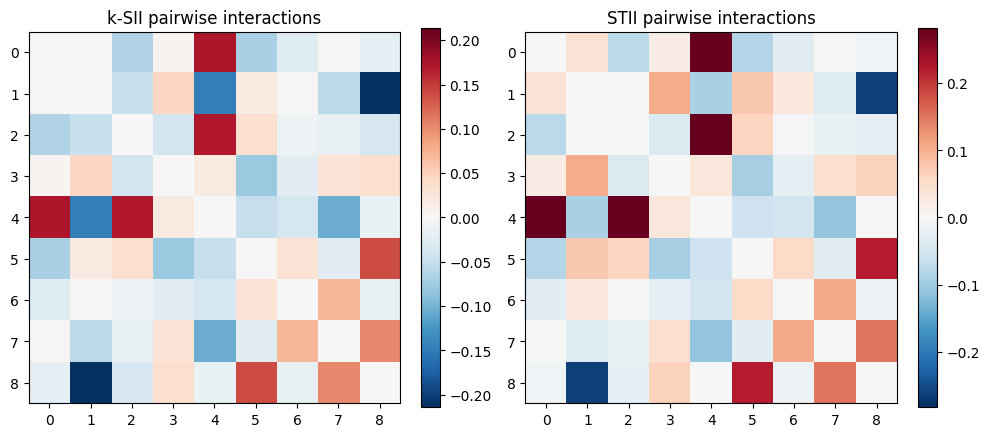

In [5]:
def pairwise_matrix(iv, n=9):
    """Off-diagonal pairwise interactions arranged as a symmetric (n, n) matrix."""
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            v = iv[(i, j)]
            mat[i, j] = v
            mat[j, i] = v
    return mat


ksii = computer.shapley_interactions(index="k-SII", order=2)
stii = computer.shapley_interactions(index="STII", order=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (iv, label) in zip(axes, [(ksii, "k-SII"), (stii, "STII")], strict=False):
    M = pairwise_matrix(iv)
    v = max(abs(M.min()), abs(M.max())) + 1e-9
    im = ax.imshow(M, cmap=cm.RdBu_r, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v))
    ax.set_title(f"{label} pairwise interactions")
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 5. How much do interactions add over first-order?

One way to quantify this is to split the variance of the game's value function across all $2^n$ coalition values into a first-order part and an interaction residual:

$$\operatorname{Var}\bigl(v(S)\bigr) = \underbrace{\operatorname{Var}\bigl(\hat v_1(S)\bigr)}_\text{first-order} + \underbrace{\operatorname{Var}\bigl(v(S) - \hat v_1(S)\bigr)}_\text{interaction residual} + \text{cross-terms}$$

We report $R^2$ of the additive reconstruction $\hat v_1(S) = v(\emptyset) + \sum_{i \in S} \phi_i$. Values near 1 mean first-order Shapley values already track the coalition scores. Low or negative $R^2$ means you need the pairwise layer.

In [6]:
from itertools import product

v_S = computer.game_values  # all 2^9 coalition values
coalitions = np.array(list(product([0, 1], repeat=9)), dtype=bool)
v_empty = float(computer.baseline_value)
additive = v_empty + coalitions @ sv_values
# Re-order additive to match the ExactComputer's coalition_lookup order:
additive_in_ec_order = np.zeros_like(v_S)
for coal, vec in zip(coalitions, additive, strict=False):
    idx = computer.coalition_lookup[tuple(np.where(coal)[0])]
    additive_in_ec_order[idx] = vec
ss_res = float(((v_S - additive_in_ec_order) ** 2).sum())
ss_tot = float(((v_S - v_S.mean()) ** 2).sum())
r2_additive = 1.0 - ss_res / max(ss_tot, 1e-12)

print(f"{'metric':<20} {'value':>30}")
print(f"{'R^2 additive':<20} {r2_additive:>30.4f}")
print()
print(
    "Interpretation: R^2 near 1 means first-order Shapley values explain almost all coalition scores."
)
print(
    "Values below 0 are fine here: the additive model can lose to simply predicting the mean coalition value, which is a strong sign that pairwise terms matter."
)

metric                                        value
R^2 additive                                -0.2575

Interpretation: R^2 near 1 means first-order Shapley values explain almost all coalition scores.
Values below 0 are fine here: the additive model can lose to simply predicting the mean coalition value, which is a strong sign that pairwise terms matter.


## 6. Strongest synergistic and redundant patch pairs

We extract the three most positive and three most negative pairwise k-SII entries.

- A **positive** entry means that removing both patches hurts the prediction more than removing them separately. The model uses them as a coupled pair.
- A **negative** entry means the patches carry overlapping evidence. Once one patch is present, the other adds little.


In [7]:
def top_pairs(M, k=3):
    triu = np.triu_indices_from(M, k=1)
    pairs = sorted(
        ((M[i, j], (i, j)) for i, j in zip(*triu, strict=False)),
        key=lambda x: x[0],
    )
    return pairs[-k:][::-1], pairs[:k]


M = pairwise_matrix(ksii)
syn, red = top_pairs(M, k=3)
print("Top synergistic pairs (positive k-SII):")
for v, (i, j) in syn:
    print(f"  patches ({i}, {j}) : {v:+.4f}")
print("Top redundant pairs (negative k-SII):")
for v, (i, j) in red:
    print(f"  patches ({i}, {j}) : {v:+.4f}")

Top synergistic pairs (positive k-SII):
  patches (0, 4) : +0.1725
  patches (2, 4) : +0.1714
  patches (5, 8) : +0.1396
Top redundant pairs (negative k-SII):
  patches (1, 8) : -0.2134
  patches (1, 4) : -0.1480
  patches (4, 7) : -0.1059


## 7. Case study: visualising one synergistic pair

We identify the single strongest synergistic pair and highlight those two patches on the image. The first-order SVs are shown as a backdrop to indicate where on the additive map the interaction sits.


Strongest synergistic pair: (0, 4) with k-SII = +0.1725


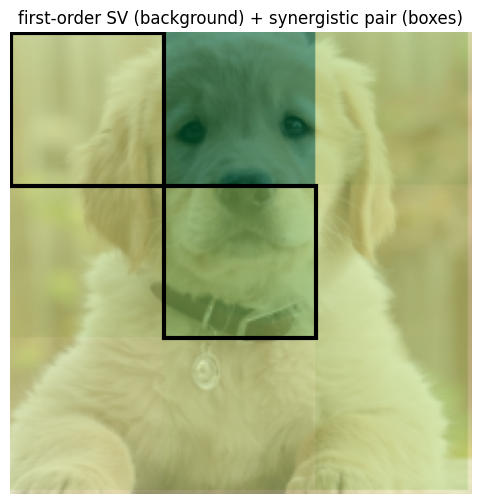

In [8]:
M = pairwise_matrix(ksii)
iu = np.triu_indices_from(M, k=1)
best_idx = int(np.argmax(M[iu]))
i_best, j_best = iu[0][best_idx], iu[1][best_idx]
print(f"Strongest synergistic pair: ({i_best}, {j_best}) with k-SII = {M[i_best, j_best]:+.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
overlay(
    ax,
    patch_heatmap(sv_values),
    "first-order SV (background) + synergistic pair (boxes)",
)

side, H, W = 3, image.shape[0], image.shape[1]
bh, bw = H // side, W // side
for p in (i_best, j_best):
    y, x = (p // side) * bh, (p % side) * bw
    ax.add_patch(plt.Rectangle((x, y), bw, bh, fill=False, edgecolor="black", linewidth=3))
plt.show()

## 8. Discussion

### What the numbers tell us

- **First-order does not capture everything.** The $R^2$ of the additive reconstruction is well below 1 (it can even be negative). Patch Shapley values alone do not track the 512 coalition scores. The gap is what second-order k-SII is for.
- **Some pairs are coupled.** The strongest synergistic pair involves two patches whose joint removal hurts the prediction far more than either patch alone. They are not necessarily the individually strongest on the additive heatmap because their importance is a *joint* effect invisible to first-order Shapley values. This is the core reason for computing higher-order interactions.
- **Masking caveat.** On `ViTForImageClassification`, `BoolMaskedPosStrategy` and `MaskTokenStrategy` coincide (zero mask token). For MAE-style checkpoints with a learned mask token, the choice of masker can change coalition values and interactions; see Tutorial 01.

### Limitations

- **Single image.** Findings on one image do not generalise. A proper study would aggregate results over a dataset.
- **9 players.** The 3×3 patch grid is a coarse discretisation. Finer grids would surface finer interactions but require approximate rather than exact computation.
- **Model fixed, masker varied elsewhere.** This notebook fixes ViT-B/16 and one masker. The companion notebook `04_cross_architecture.ipynb` fixes the masker and varies the architecture.

### `shapiq` and this experiment

Computing $2^9=512$ exact coalition values and the full quadratic-order interaction decomposition requires only a few lines with `ExactComputer`. The same machinery scales to approximate computation for larger grids via `ImageExplainer`.


---

## 10. Reproducing FIxLIP: weighted Banzhaf interactions for CLIP

**Reference:** Baniecki et al., *Explaining Similarity in Vision–Language Encoders with Weighted Banzhaf Interactions* (FIxLIP), arXiv:2508.05430, 2025.

### What is FIxLIP?

First-order attribution maps over image patches or text tokens cannot, by construction, express **cross-modal interactions**: the coupling between an image region and a text token that jointly drives CLIP's similarity prediction. FIxLIP formalises this as a cooperative game over the joint player set $N_\mathcal{I} \cup N_\mathcal{T}$ (image patches + text tokens) and approximates second-order interactions via weighted Banzhaf regression:

$$\hat{\nu}_{\mathbf{e}}(M) \coloneqq \mathbf{e}_0 + \sum_{i \in M} \mathbf{e}_i + \sum_{\{i,j\} \subseteq M} \mathbf{e}_{\{i,j\}}$$

The parameter $p \in (0,1)$ weights each coalition by $p^{|M|}(1-p)^{n-|M|}$ in the $p$-faithfulness objective. Values above $0.5$ put more weight on nearly complete masks. At $p = 0.5$ you recover the usual faithful Banzhaf index.

In this section we:
1. Define the **FIxLIP game**: CLIP similarity (`logits_per_image`) over jointly masked image–text inputs.
2. Approximate FIxLIP-$p$ with a small `RegressionFixLIP` wrapper around `RegressionFBII` that sets **regression kernel weights** to $p^k(1-p)^{n-k}$ (not only coalition-size sampling).
3. Decompose the result into **intra-modal image**, **intra-modal text**, and **cross-modal** interaction matrices.
4. Compare the cross-modal view with naive first-order CLIP attribution.


### 10.1  Setup: CLIP model and tokenization

In [9]:
from __future__ import annotations

import numpy as np
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

CLIP_ID = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(CLIP_ID)
clip_model = CLIPModel.from_pretrained(CLIP_ID).eval().to(device)

# Same golden-retriever photo as in section 1. Match the caption so CLIP has a clear target.
TEXT_PROMPT = "a golden retriever"
print(f"Model: {CLIP_ID}")
print(f"Text prompt: {TEXT_PROMPT!r}")

# Sanity check: CLIP should prefer the matching caption over a mismatched one.
inputs = clip_processor(
    text=[TEXT_PROMPT, "a tabby cat"],
    images=Image.fromarray(image),
    return_tensors="pt",
    padding=True,
).to(device)
with torch.no_grad():
    out = clip_model(**inputs)
    probs = out.logits_per_image.softmax(dim=-1)[0].cpu().numpy()
print(f"Zero-shot: retriever {probs[0]:.2%}, tabby cat {probs[1]:.2%}")

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: openai/clip-vit-base-patch32
Text prompt: 'a golden retriever'
Zero-shot: retriever 100.00%, tabby cat 0.00%


### 10.2  Define the FIxLIP game

Players:
- $0, \ldots, N_\mathcal{I}-1$ = image patches (3×3 macro-grid → 9 patches)
- $N_\mathcal{I}, \ldots, N_\mathcal{I}+N_\mathcal{T}-1$ = real text tokens (excluding BOS/EOS)

Value function: CLIP `logits_per_image` for each masked pair (same forward pass as zero-shot CLIP).

Image masking: mean-colour fill for absent macro-patches. This is a coarse grid for the notebook. The paper masks at native ViT patch resolution.

Text masking follows the reference FIxLIP code: **attention masking**. `input_ids` stay fixed, BOS and EOS always attend, and absent content tokens are turned off in `attention_mask`.


In [10]:
class FIxLIPGame:
    """
    Cooperative game for FIxLIP-p Weighted Banzhaf Interactions with CLIP.

    Players: 0..n_image-1 are image patches. n_image..n_image+n_text-1 are text tokens.
    Value  : CLIP logits_per_image for jointly masked image–text pairs.
    """

    def __init__(
        self,
        clip_model,
        clip_processor,
        image: np.ndarray,
        text: str,
        *,
        n_image_patches: int = 9,
        batch_size: int = 32,
        device: str | torch.device = "cpu",
    ) -> None:
        self.model = clip_model
        self.processor = clip_processor
        self.device = device
        self.batch_size = batch_size
        self.n_image = n_image_patches
        self._image = image.copy()

        # ── Text tokenisation ───────────────────────────────────────────────────
        tok = clip_processor.tokenizer(
            text, return_tensors="pt", padding=False, truncation=True, max_length=77
        )
        # Full token sequence including BOS/EOS stored on device
        self._full_ids = tok.input_ids.to(device)  # (1, L)
        # Real tokens (everything except BOS at index 0 and EOS at end)
        real = self._full_ids[0, 1:-1]
        self.n_text = int((real != 0).sum().item())
        self.n_players = n_image_patches + self.n_text
        print(
            f"FIxLIPGame: {n_image_patches} image patches + {self.n_text} text tokens"
            f" = {self.n_players} players"
        )

        # ── Pre-compute patch masks ──────────────────────────────────────────────
        H, W = image.shape[:2]
        side = int(round(n_image_patches**0.5))
        assert side * side == n_image_patches, "n_image_patches must be a perfect square"
        bh, bw = H // side, W // side
        self._patch_masks: list[np.ndarray] = []
        for idx in range(n_image_patches):
            r, c = idx // side, idx % side
            m = np.zeros((H, W), dtype=bool)
            m[r * bh : (r + 1) * bh, c * bw : (c + 1) * bw] = True
            self._patch_masks.append(m)
        self._mean_color: np.ndarray = image.mean(axis=(0, 1))  # (3,)

    # ── Internal helpers ────────────────────────────────────────────────────────
    def _apply_image_mask(self, img_flags: np.ndarray) -> np.ndarray:
        """img_flags: bool (n_image,). True means the patch is present."""
        out = self._image.astype(float)
        for i, active in enumerate(img_flags):
            if not active:
                out[self._patch_masks[i]] = self._mean_color
        return out.astype(np.uint8)

    def _text_attention_mask(self, txt_flags: np.ndarray) -> torch.Tensor:
        """txt_flags: bool (n_text,). True means the token attends. BOS and EOS always attend."""
        att = torch.zeros_like(self._full_ids, dtype=torch.long)
        att[0, 0] = 1
        for j, active in enumerate(txt_flags):
            att[0, j + 1] = int(active)
        att[0, -1] = 1
        return att

    # ── Value function ──────────────────────────────────────────────────────────
    def __call__(self, coalitions: np.ndarray) -> np.ndarray:
        """
        Args:
            coalitions: bool array of shape (B, n_players).
        Returns:
            similarities: float array of shape (B,).
        """
        results: list[np.ndarray] = []
        for start in range(0, len(coalitions), self.batch_size):
            chunk = coalitions[start : start + self.batch_size]
            batch_pixels, batch_atts = [], []
            for coalition in chunk:
                img_flags = coalition[: self.n_image]
                txt_flags = coalition[self.n_image :]
                masked_img = self._apply_image_mask(img_flags)
                proc = self.processor(images=Image.fromarray(masked_img), return_tensors="pt")
                batch_pixels.append(proc.pixel_values)
                batch_atts.append(self._text_attention_mask(txt_flags))

            pixel_values = torch.cat(batch_pixels).to(self.device)
            batch_size = pixel_values.shape[0]
            input_ids = self._full_ids.repeat(batch_size, 1)
            attention_masks = torch.cat(batch_atts, dim=0).to(self.device)

            with torch.no_grad():
                out = self.model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_masks,
                )
                logits = out.logits_per_image
                sims = torch.diagonal(logits).cpu().numpy()
            results.append(sims)
        return np.concatenate(results)


game = FIxLIPGame(
    clip_model, clip_processor, image, TEXT_PROMPT, n_image_patches=9, batch_size=32, device=device
)
N_PLAYERS_FIXLIP = game.n_players

FIxLIPGame: 9 image patches + 3 text tokens = 12 players


### 10.3  Approximate FIxLIP-$p$ with `RegressionFixLIP`

FIxLIP-$p$ is a **weighted** faithful Banzhaf regression: coalition masks of size $k$ enter the least-squares objective with kernel weight $p^k(1-p)^{n-k}$ (Definition 4). `RegressionFBII` alone fixes that kernel to $2^{-n}$. We subclass it so the kernel depends on $p$.

Coalition **sampling** uses size probabilities $\binom{n}{k} p^k (1-p)^{n-k}$ (normalised), as in the [reference implementation](https://github.com/hbaniecki/fixlip). We compare $p=0.5$ (faithful Banzhaf) and $p=0.7$ (in-distribution bias) with separate random seeds.

`BUDGET` is a trade-off between runtime and stability. The paper spends far more coalition evaluations. After each fit we print how well the second-order expansion reproduces the grand-coalition CLIP score.


In [11]:
from math import comb

from shapiq.approximator import RegressionFBII


class RegressionFixLIP(RegressionFBII):
    """`RegressionFBII` with FIxLIP-p regression kernel weights."""

    def __init__(self, *, p: float, **kwargs) -> None:
        self._fixlip_p = p
        super().__init__(**kwargs)

    def _init_kernel_weights(self, interaction_size: int) -> np.ndarray:
        return np.array(
            [self._fixlip_p**k * (1.0 - self._fixlip_p) ** (self.n - k) for k in range(self.n + 1)],
            dtype=float,
        )


def p_weights(n: int, p: float) -> np.ndarray:
    """Normalised coalition-size sampling weights for FIxLIP-p."""
    w = np.array([comb(n, k) * p**k * (1.0 - p) ** (n - k) for k in range(n + 1)], dtype=float)
    return w / w.sum()


def reconstruct_second_order(iv, coalition: np.ndarray) -> float:
    """Evaluate the fitted 2-additive FIxLIP expansion on one coalition mask."""
    val = float(iv.baseline_value)
    active = [i for i in range(coalition.size) if coalition[i]]
    for i in active:
        val += iv[(i,)]
    for a in range(len(active)):
        for b in range(a + 1, len(active)):
            i, j = active[a], active[b]
            val += iv[(min(i, j), max(i, j))]
    return val


BUDGET = 2000  # coalition evaluations (paper uses much larger budgets)

fixlip_results: dict[str, object] = {}
grand_coalition = np.ones(N_PLAYERS_FIXLIP, dtype=bool)
empty_coalition = np.zeros(N_PLAYERS_FIXLIP, dtype=bool)
grand_score = float(game(grand_coalition[None])[0])
empty_score = float(game(empty_coalition[None])[0])

for seed, p_val in enumerate((0.5, 0.7)):
    label = f"p={p_val}"
    approx = RegressionFixLIP(
        p=p_val,
        n=N_PLAYERS_FIXLIP,
        max_order=2,
        sampling_weights=p_weights(N_PLAYERS_FIXLIP, p_val),
        random_state=seed,
    )
    iv = approx.approximate(budget=BUDGET, game=game)
    fixlip_results[label] = iv
    recon = reconstruct_second_order(iv, grand_coalition)
    e1_norm = float(np.abs([iv[(i,)] for i in range(N_PLAYERS_FIXLIP)]).sum())
    print(f"[{label}]  grand CLIP score = {grand_score:.4f}  empty = {empty_score:.4f}")
    print(
        f"         e_0 = {iv.baseline_value:.4f}  recon at grand = {recon:.4f}  "
        f"error = {recon - grand_score:+.4f}  sum|e_i| = {e1_norm:.4f}"
    )

[p=0.5]  grand CLIP score = 30.2319  empty = 22.5441
         e_0 = 22.5441  recon at grand = 30.6708  error = +0.4390  sum|e_i| = 8.9687
[p=0.7]  grand CLIP score = 30.2319  empty = 22.5441
         e_0 = 22.5441  recon at grand = 31.4335  error = +1.2016  sum|e_i| = 11.9591


### 10.4  Decompose into intra- and cross-modal interaction matrices

We extract three blocks of the full $(N_\mathcal{I}+N_\mathcal{T})\times(N_\mathcal{I}+N_\mathcal{T})$ interaction matrix:

| Block | Rows | Columns | Meaning |
|-------|------|---------|---------|
| $\Phi_{II}$ | image patches | image patches | intra-image synergy / redundancy |
| $\Phi_{IT}$ | image patches | text tokens | **cross-modal interactions** |
| $\Phi_{TT}$ | text tokens | text tokens | intra-text synergy / redundancy |

Positive entries = synergy (the pair matters more jointly than the sum of their individual contributions). Negative entries = redundancy.


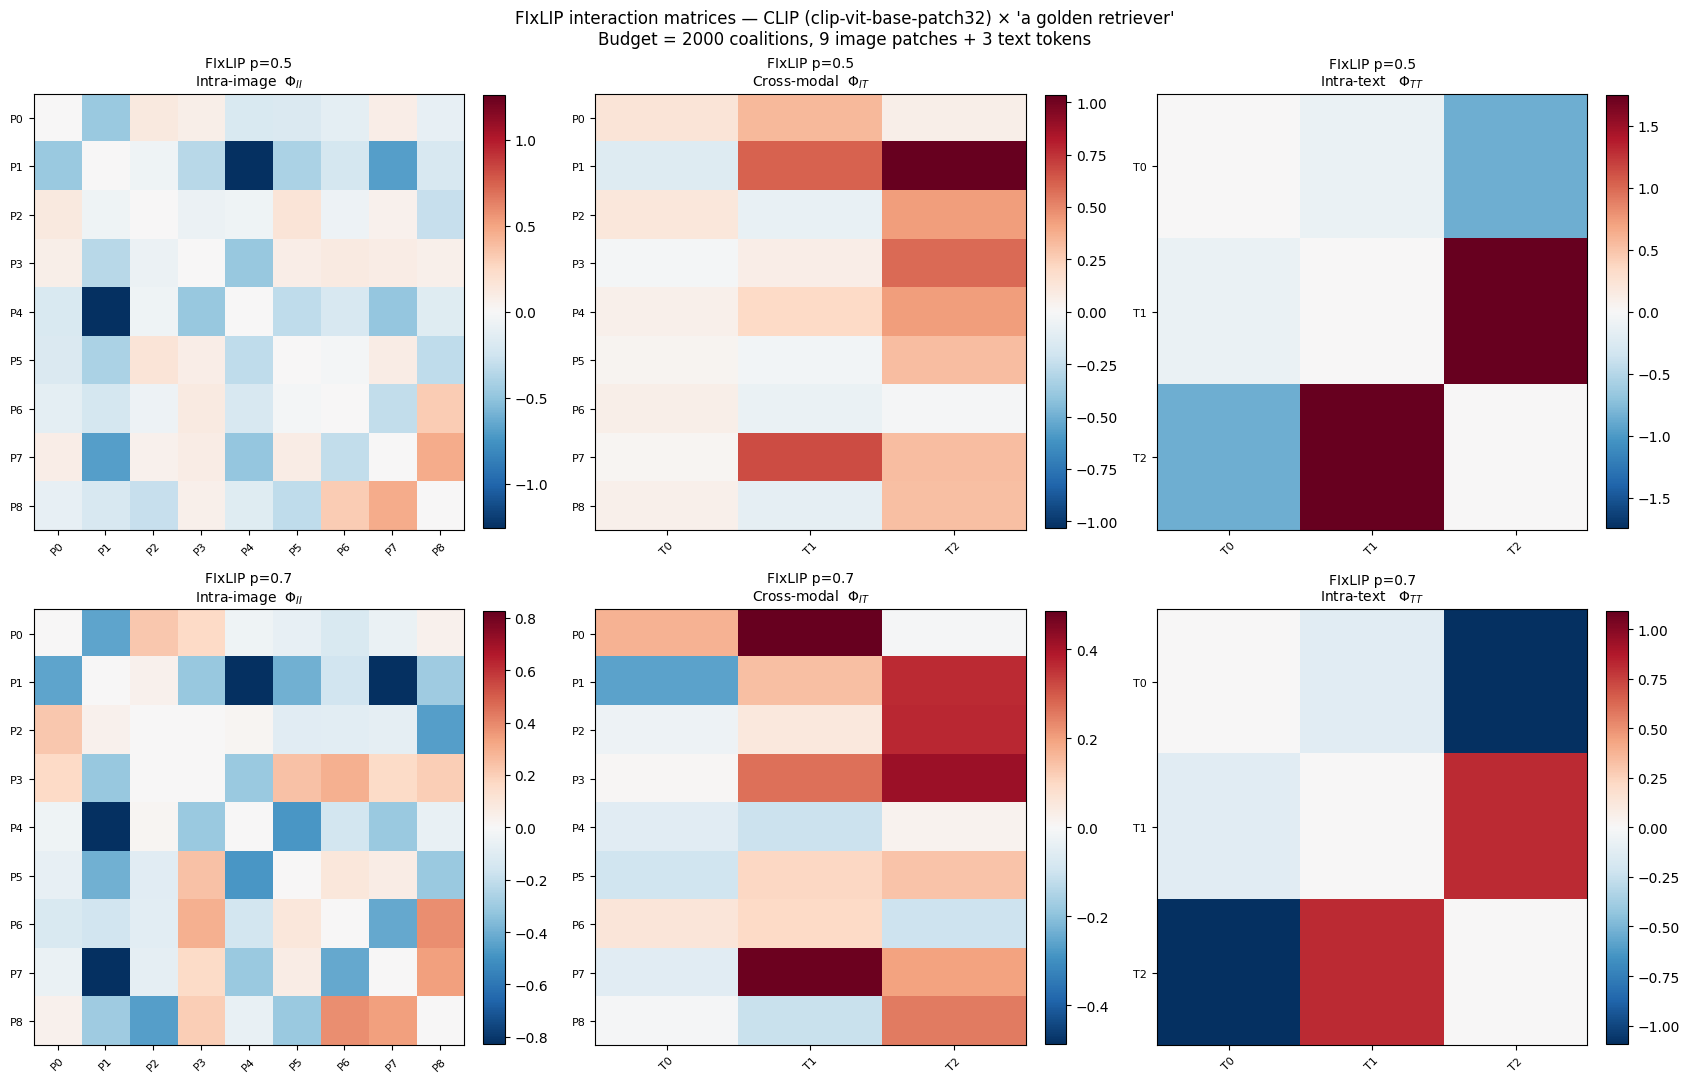

In [12]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import cm

n_i = game.n_image
n_t = game.n_text


def interaction_matrix(iv, n: int) -> np.ndarray:
    """Extract the full (n, n) second-order interaction matrix from an InteractionValues."""
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            val = iv[(i, j)]
            mat[i, j] = val
            mat[j, i] = val
    return mat


def block(mat, r_slice, c_slice):
    return mat[np.ix_(r_slice, c_slice)]


fig, axes = plt.subplots(2, 3, figsize=(17, 11))
x_labels_i = [f"P{i}" for i in range(n_i)]
x_labels_t = [f"T{j}" for j in range(n_t)]

for row_idx, (label, iv) in enumerate(fixlip_results.items()):
    M = interaction_matrix(iv, N_PLAYERS_FIXLIP)
    I_idx = list(range(n_i))
    T_idx = list(range(n_i, n_i + n_t))

    for col_idx, (block_mat, title, xl, yl) in enumerate(
        [
            (block(M, I_idx, I_idx), r"Intra-image  $\Phi_{II}$", x_labels_i, x_labels_i),
            (block(M, I_idx, T_idx), r"Cross-modal  $\Phi_{IT}$", x_labels_t, x_labels_i),
            (block(M, T_idx, T_idx), r"Intra-text   $\Phi_{TT}$", x_labels_t, x_labels_t),
        ]
    ):
        ax = axes[row_idx, col_idx]
        v = max(abs(block_mat.min()), abs(block_mat.max())) + 1e-9
        im = ax.imshow(block_mat, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto")
        ax.set_title(f"FIxLIP {label}\n{title}", fontsize=10)
        ax.set_xticks(range(len(xl)))
        ax.set_xticklabels(xl, rotation=45, fontsize=8)
        ax.set_yticks(range(len(yl)))
        ax.set_yticklabels(yl, fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f"FIxLIP interaction matrices — CLIP ({CLIP_ID.rsplit('/', maxsplit=1)[-1]}) × '{TEXT_PROMPT}'\n"
    f"Budget = {BUDGET} coalitions, 9 image patches + {n_t} text tokens",
    fontsize=12,
)
plt.tight_layout()
plt.show()

### 10.5  Visualise cross-modal attribution on the image

First-order terms and FIxLIP marginalised first-order values from Theorem 1:
$$\bar{e}_i = e_i + p \sum_{j \neq i} e_{\{i,j\}}$$

The left column is plain $e_i$ on image patches. The middle column folds in every cross-modal pair that touches the patch. The right column labels each patch with the text token that has the largest **positive** entry in the cross-modal block (negative couplings are omitted there on purpose).


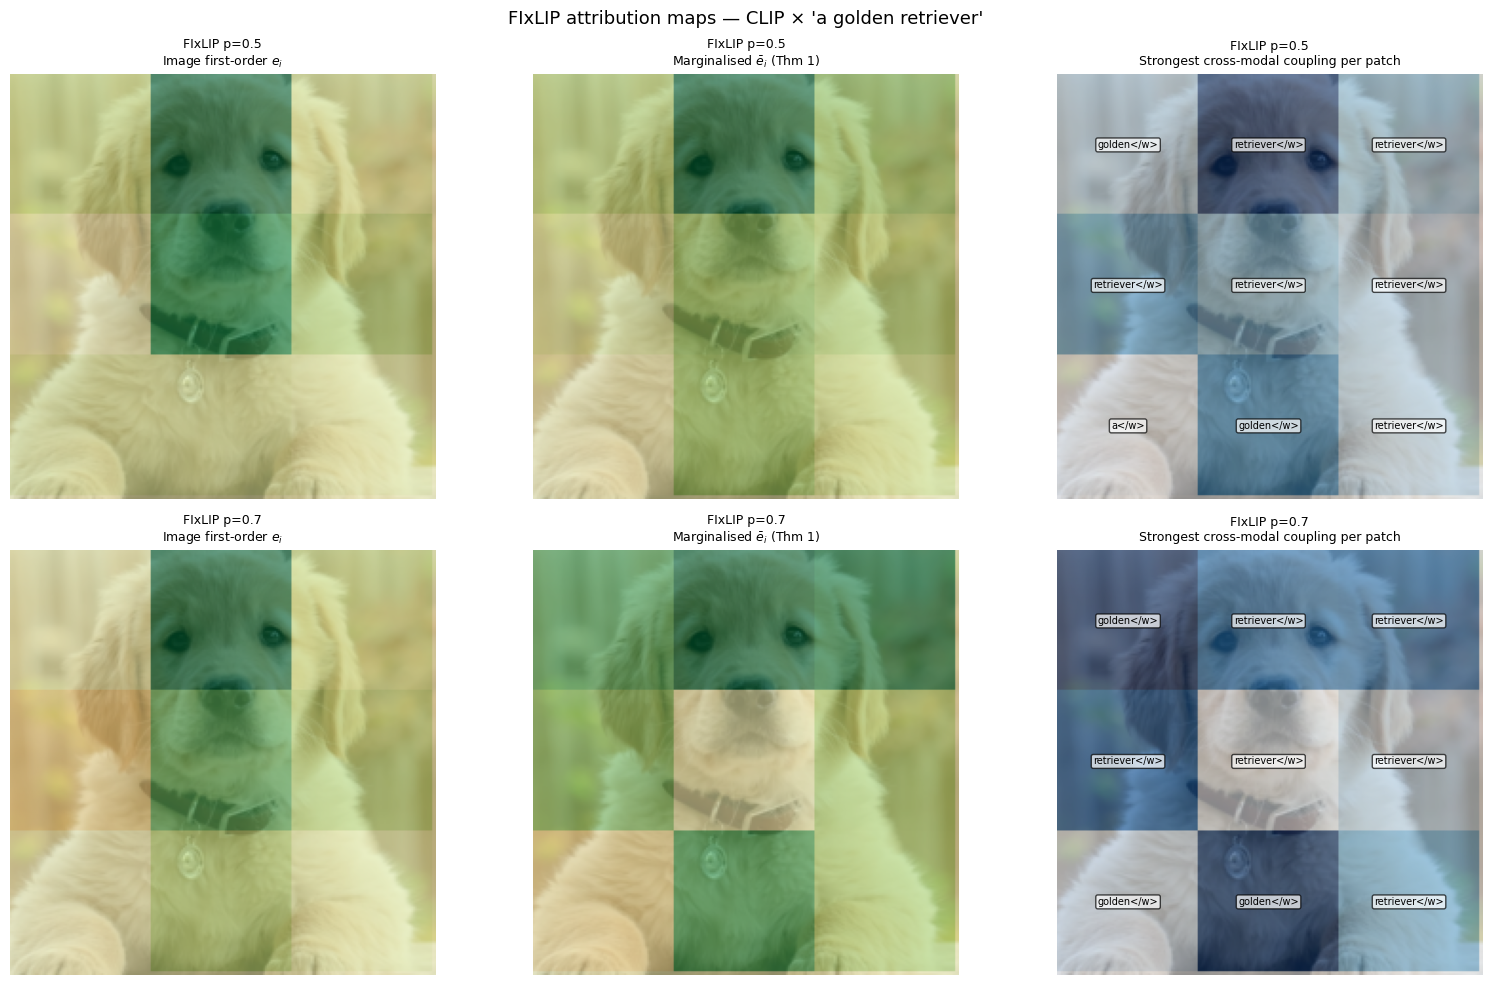

In [13]:
def marginalised_first_order(iv, player_idx: list[int], p: float, n_players: int) -> np.ndarray:
    """Theorem 1: marginalised attribution for a subset of players."""
    attrs = np.array([iv[(i,)] for i in player_idx], dtype=float)
    for k, i in enumerate(player_idx):
        for j in range(n_players):
            if j in player_idx and j == i:
                continue
            attrs[k] += p * iv[(min(i, j), max(i, j))]
    return attrs


def patch_heatmap_from_masks(values: np.ndarray, masks: list[np.ndarray]) -> np.ndarray:
    h = np.zeros(image.shape[:2], dtype=float)
    for v, m in zip(values, masks, strict=False):
        h[m] = v
    return h


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
tok_text = clip_processor.tokenizer.convert_ids_to_tokens(
    clip_processor.tokenizer(TEXT_PROMPT)["input_ids"][1:-1][:n_t]
)

for row_idx, (label, iv) in enumerate(fixlip_results.items()):
    p_val = float(label.split("=")[1])

    # First-order (SV-like) image attributions
    sv_img = np.array([iv[(i,)] for i in range(n_i)])
    heat_sv = patch_heatmap_from_masks(sv_img, game._patch_masks)
    v = max(abs(heat_sv.min()), abs(heat_sv.max())) + 1e-9
    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].imshow(
        heat_sv, cmap=cm.RdYlGn, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), alpha=0.55
    )
    axes[row_idx, 0].set_title(f"FIxLIP {label}\nImage first-order $e_i$", fontsize=9)
    axes[row_idx, 0].axis("off")

    # Marginalised first-order (includes cross-modal couplings)
    marg = marginalised_first_order(iv, list(range(n_i)), p=p_val, n_players=N_PLAYERS_FIXLIP)
    heat_m = patch_heatmap_from_masks(marg, game._patch_masks)
    v2 = max(abs(heat_m.min()), abs(heat_m.max())) + 1e-9
    axes[row_idx, 1].imshow(image)
    axes[row_idx, 1].imshow(
        heat_m, cmap=cm.RdYlGn, norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v2, vmax=v2), alpha=0.55
    )
    axes[row_idx, 1].set_title(f"FIxLIP {label}\nMarginalised $\\bar{{e}}_i$ (Thm 1)", fontsize=9)
    axes[row_idx, 1].axis("off")

    # Cross-modal attributions: which text token interacts most with each image patch?
    M = interaction_matrix(iv, N_PLAYERS_FIXLIP)
    cross = M[:n_i, n_i:]  # (n_image, n_text)
    # For each image patch, find the text token with strongest interaction
    best_tok_per_patch = cross.argmax(axis=1)
    best_val_per_patch = cross.max(axis=1)
    heat_cross = patch_heatmap_from_masks(best_val_per_patch, game._patch_masks)
    v3 = max(abs(heat_cross.min()), abs(heat_cross.max())) + 1e-9
    axes[row_idx, 2].imshow(image)
    axes[row_idx, 2].imshow(heat_cross, cmap="Blues", vmin=0, vmax=v3, alpha=0.55)
    # Annotate each patch with the best-interacting token
    H, W = image.shape[:2]
    side = 3
    bh, bw = H // side, W // side
    for idx in range(n_i):
        r, c = idx // side, idx % side
        cx, cy = c * bw + bw // 2, r * bh + bh // 2
        tok_label = (
            tok_text[best_tok_per_patch[idx]] if best_tok_per_patch[idx] < len(tok_text) else "?"
        )
        axes[row_idx, 2].text(
            cx,
            cy,
            tok_label,
            ha="center",
            va="center",
            fontsize=7,
            color="black",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )
    axes[row_idx, 2].set_title(
        f"FIxLIP {label}\nStrongest cross-modal coupling per patch", fontsize=9
    )
    axes[row_idx, 2].axis("off")

plt.suptitle(
    f"FIxLIP attribution maps — CLIP × '{TEXT_PROMPT}'",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### 10.6  Discussion

**Cross-modal terms.** Marginalised $\bar{e}_i$ can disagree with the plain patch scores $e_i$ when a patch talks to specific tokens. That is the point of keeping text players in the game instead of explaining the image alone.

**The role of $p$.** Sampling weights and regression kernel weights both depend on $p$. If only sampling changes, you keep estimating the same Banzhaf index and the two rows in the plots would look almost identical. `RegressionFixLIP` changes the index itself. Compare the printed `sum|e_i|` and `error` lines for $p=0.5$ and $p=0.7$.

**Faithfulness vs budget.** The `error` line is the gap between the true grand-coalition CLIP score and the fitted second-order expansion. It should shrink if you raise `BUDGET`. The paper also batches image and text masks separately for speed. We stick to one joint sampler and a $3\times3$ image grid so the code stays short.

**Link to Sections 1–8.** ViT explains a class probability on a $3\times3$ grid with exact interactions. CLIP explains a text match with approximate FIxLIP. Same shapiq regression machinery, different model and player set.
